In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_train = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_train_eda.csv')
df_test  = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_test_eda.csv')

Тут у меня появилась, как мне казалось, гениальная идея - добавить полиномаильные признаки цены в лин рег.
Обьясню откуда идея возникла: 

В будущем я буду оценивать важность признаков с помощью RFR и окажется, что цена имеет самую высокую важность, но корреляция между ценой и таргетом  - вообще 0.35, а значит между ними есть какая-то сильная зависимоть, но она не линейная.

Результат этой затеи - в конце.
* также я решила опробовать CatBoost в обучении.

In [1]:
from Splitter import Splitter

splitter = Splitter(time_col = 'date_block_num', train_end = 33)

In [10]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_test = df_test.merge(
    df_testt,
    on = ['shop_id','item_id'],
    how = 'left'
)

In [11]:
features =['cnt_lag_1','cnt_lag_3','cnt_lag_2','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','item_avg_price_prev', 'item_price','date_block_num','avg_price_prev_missing']


In [12]:
X_tr, y_tr, X_val, y_val = splitter.split(
    df_train,
    features,            
    target_col="item_cnt_month"
)
X_full = pd.concat([X_tr, X_val], axis=0)
y_full = pd.concat([y_tr, y_val], axis=0)


In [13]:
X = X_full.copy()
X['log_item_price'] = np.log1p(X['item_price'])
X['log_item_price_2'] = X['log_item_price']**2
X['log_item_price_3'] = X['log_item_price']**3
X['log_item_price_4'] = X['log_item_price']**4



In [47]:
df_full = pd.concat([X, y_full], axis = 1 )


In [48]:
df_full.head()

,cnt_lag_1,cnt_lag_3,cnt_lag_2,cnt_lag_12,cnt_rm_3,cnt_rm_6,item_avg_price_prev,item_price,date_block_num,avg_price_prev_missing,log_item_price,log_item_price_2,log_item_price_3,log_item_price_4,item_cnt_month
0,0.0,0.0,0.0,0.0,0.000000,0.000000,199.0,0.0,0,1,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.000000,199.0,0.0,1,1,0.000000,0.000000,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.000000,199.0,359.0,2,1,5.886104,34.646221,203.931259,1200.360607,1.0
3,1.0,0.0,0.0,0.0,0.333333,0.333333,359.0,0.0,3,0,0.000000,0.000000,0.000000,0.000000,0.0
4,0.0,0.0,1.0,0.0,0.333333,0.250000,199.0,0.0,4,1,0.000000,0.000000,0.000000,0.000000,0.0


In [49]:
df_full.isna().sum()

cnt_lag_1                 0
cnt_lag_3                 0
cnt_lag_2                 0
cnt_lag_12                0
cnt_rm_3                  0
cnt_rm_6                  0
item_avg_price_prev       0
item_price                0
date_block_num            0
avg_price_prev_missing    0
log_item_price            0
log_item_price_2          0
log_item_price_3          0
log_item_price_4          0
item_cnt_month            0
dtype: int64

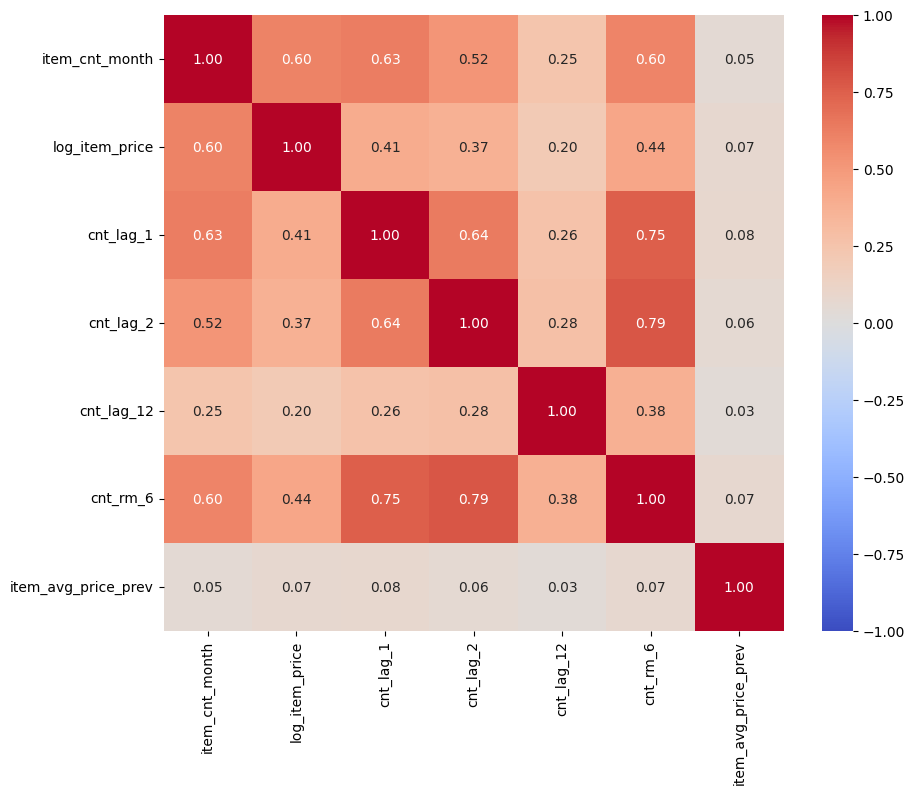

In [50]:
cols = [
    'item_cnt_month',
    'log_item_price',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_12',
    'cnt_rm_6',
    'item_avg_price_prev'
]

corr = df_full[cols].corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.show()


In [51]:
from Validator import Validator
from math import sqrt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [52]:
cols = [
    'item_cnt_month',
    'log_item_price_4',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_12',
    'cnt_rm_6',
    'item_avg_price_prev',
    'date_block_num',
    'avg_price_prev_missing'
]
features = [
    'log_item_price_4',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_12',
    'cnt_rm_6',
    'item_avg_price_prev',
    'date_block_num',
    'avg_price_prev_missing'
]



df_train = df_full[cols]
validator = Validator(df_train, splitter, model = Ridge( alpha = 1.0), metric   = lambda y, yhat: sqrt(mean_squared_error(y, yhat)))
result = validator.run(features, target_col = 'item_cnt_month')

print('Val RMSE:', result)

Val RMSE: {'val_score': 0.8213665529339328, 'pred_val': array([0.00579757, 0.84252033, 0.16468049, ..., 0.10868605, 0.00130147,
       0.00130147], shape=(214200,))}


In [53]:
model = Ridge(alpha =1.0)
model.fit(df_full[features], y_full)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [16]:
X_test= df_test.copy()
X_test['log_item_price'] = np.log1p(X_test['item_price'])
X_test['log_item_price_2'] = X_test['log_item_price']**2
X_test['log_item_price_3'] = X_test['log_item_price']**3
X_test['log_item_price_4'] = X['log_item_price']**4


In [55]:
X_test = X_test[features]

In [56]:
preds = model.predict(X_test)

In [57]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

submission.to_csv("submissionRidgeLogPrice4.csv", index=False)

In [5]:
from catboost import CatBoostRegressor

In [6]:
model = CatBoostRegressor(random_seed = 42, verbose = False)


In [14]:
model.fit(X, y_full )

In [17]:
preds = model.predict(X_test)

In [18]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

submission.to_csv("submissionCatBoost.csv", index=False)

Результат:
- вместо обычной фичи цены ее лог трансформация - 1.07484
- вместо обычной фичи цены ее лог трансформация в квадрате - 1.07036
- вместо обычной фичи цены ее лог трансформация в кубе - 1.06243
- вместо обычной фичи цены ее лог трансформация в 4 степени - 1.10683
Видим, дальше степень нет смысла повышать
Все это хорошо, но вот результат обычной лин рег никто из них не побил - 1.03054
* catboost - 1.53542 
Если посмотреть, как эта идея отработала на валидационной выборке - то лучше, чем когда обычная цена, но из-за огромного количества пропусков в тестовом наборе цены видимо идея и не удалась.